# hBN NNSK-SCC smoke test

This notebook checks the decoupled SCC path: the Hamiltonian and overlap are provided by a baseline NNSK model, while SCC parameters such as Hubbard U, occupation, mass, and cutoffs are read from the hBN DFTB SK files.

In [1]:
from pathlib import Path
import tempfile

import numpy as np
import torch

from ase.io import read
from dptb.data import AtomicDataDict
from dptb.entrypoints.emp_sk import to_empsk
from dptb.nn.build import build_model
from dptb.nn.dftb.dftb_scc import SKSCC
from dptb.nn.dftb.sk_param import SKParam
from dptb.nn.dftb.scc_params import SCCParams
from dptb.postprocess.bandstructure.band import Band
from dptb.postprocess.elec_struc_cal import ElecStruCal
from dptb.utils.make_kpoints import abacus_kpath
from dptb.utils.tools import j_loader

In [2]:
def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "dptb").is_dir():
            return path
    raise RuntimeError("Could not find DeePTB repo root from the current working directory.")


repo = find_repo_root()
example_dir = repo / "examples" / "dftb_scc" / "hBN_scc"
baseline_conf = repo / "examples" / "base_model" / "confs" / "hbn_sp.json"
nnsk_dir = Path(tempfile.gettempdir()) / "deeptb_hbn_nnsk_scc"
nnsk_json = nnsk_dir / "sktb.json"

struct = example_dir / "data" / "struct.vasp"
sk_path = example_dir / "slakos"

repo, baseline_conf, nnsk_json, struct, sk_path

(PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/base_model/confs/hbn_sp.json'),
 PosixPath('/var/folders/_1/h95y6cxd14vgh0v48xmkmth40000gn/T/deeptb_hbn_nnsk_scc/sktb.json'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/dftb_scc/hBN_scc/data/struct.vasp'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/dftb_scc/hBN_scc/slakos'))

Generate a baseline hBN `s,p` NNSK JSON. The baseline model contains overlap parameters, which are required by the current nonorthogonal Mulliken/SCC implementation.

In [3]:
nnsk_dir.mkdir(parents=True, exist_ok=True)
to_empsk(str(baseline_conf), output=str(nnsk_dir), basemodel="poly2")

model = build_model(str(nnsk_json))
model.eval()

print(type(model).__name__)
print("basis:", model.basis)
print("dtype:", model.dtype)
print("has overlap:", hasattr(model, "overlap_param"))

CUDA is not available. The model will be loaded on CPU.


NNSK
basis: {'B': ['s', 'p'], 'N': ['s', 'p']}
dtype: torch.float32
has overlap: True


Read SCC metadata from the existing hBN SK files. In this test, the NNSK model supplies `H` and `S`; `SKParam` is only used as the source of SCC parameters.

In [4]:
sk_basis = {"B": ["2s", "2p"], "N": ["2s", "2p"]}
skp = SKParam(basis=sk_basis, skdata=str(sk_path), cal_rcuts=True, dtype=torch.float64)
scc_params = SCCParams.from_skparam(skp)

print("r_max:", scc_params.r_max)
print("available SCC fields:", sorted(scc_params.skdict))
print("Highest_Occu_U:")
print(scc_params.skdict["Highest_Occu_U"].detach().cpu().numpy())

r_max: {'B': 4.37, 'N': 4.18}
available SCC fields: ['Highest_Occu_U', 'HubdU', 'Mass', 'Occu']
Highest_Occu_U:
[[[10.35257244]]

 [[13.30092525]]]


Run a moderate SCC calculation. The mesh below is intentionally lighter than the DFTB-SK notebook so this notebook can be used as a quick regression check.

In [5]:
scc = SKSCC(model=model, params=scc_params, overlap=True, scc_dtype=torch.float64)

scc.run_iters(
    data=str(struct),
    nel_atom={"B": 3, "N": 5},
    kmeshgrid=[6, 6, 1],
    kgamma_center=True,
    krotational_symmetry=False,
    ktime_inversion_symmetry=True,
    AtomicData_options={"r_max": scc_params.r_max},
    mix_rate=0.25,
    max_iter=100,
    Temp=0.1,
    smearing_method="Fermi-Dirac",
)

print("converged:", scc.is_converged)
print("E_fermi:", scc.E_fermi)
print("elec_H0_bandE:", scc.elec_H0_bandE)
print("scc_shift_energy:", scc.scc_shift_energy)
print("elec_totE:", scc.elec_totE)
print("Mulliken charge:", scc.mulliken.mul_charge)

Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'B': 4.37, 'N': 4.18}
This is very dangerous, please make sure you know what you are doing.
/Users/aisiqg/Desktop/work/github/DeePTB/.venv/lib/python3.10/site-packages/torch/nested/__init__.py:107: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:180.)
  return torch._nested_tensor_from_tensor_list(ts, dtype, None, device, None)
/Users/aisiqg/Desktop/work/github/DeePTB/dptb/utils/occupy.py:150: RuntimeWarning: divide by zero encountered in log
  out[mask_in_limit] = -f_valid * np.log(f_valid) - f1_valid * np.log(f1_valid)
/Users/aisiqg/Desktop/work/github/DeePTB/dptb/utils/occupy.py:150: RuntimeWarning: invalid value encountered in multiply
  out[mask_in_limit] = -f_valid * np.log(f_valid) - f1_valid * np.log(f1_valid)


converged: True
E_fermi: -5.1586344132716935
elec_H0_bandE: tensor([-94.1230], dtype=torch.float64)
scc_shift_energy: tensor(0.2295, dtype=torch.float64)
elec_totE: tensor([-93.8935], dtype=torch.float64)
Mulliken charge: [5.5102341 2.4897659]


In [6]:
eigvals = scc.data[AtomicDataDict.ENERGY_EIGENVALUE_KEY][0]

assert scc.is_converged
assert torch.isfinite(scc.elec_totE).all()
assert torch.isfinite(eigvals).all()
assert np.isfinite(scc.mulliken.mul_charge).all()

eigvals.shape

torch.Size([20, 8])

Plot the SCC band structure on the hBN reference k-path. Here we reuse the converged SCC shift, rebuild `H(k)` and `S(k)` on the band path with the NNSK model, and then diagonalize the SCC-corrected Hamiltonian.

In [7]:
def resolve_example_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    return example_dir / str(path_value).removeprefix("./")


jdata = j_loader(str(example_dir / "band.json"))
kpath_kwargs = jdata["task_options"]
structase = read(str(struct), format="vasp")

klist, xlist, high_sym_kpoints = abacus_kpath(
    structase=structase,
    kpath=kpath_kwargs["kpath"],
)
labels = kpath_kwargs["klabels"]
ref_band = resolve_example_path(kpath_kwargs["ref_band"])
E_fermi = float(scc.E_fermi)

scc.data[AtomicDataDict.KPOINT_KEY] = torch.nested.as_nested_tensor([
    torch.as_tensor(klist, dtype=scc.model.dtype, device=scc.model.device)
])
scc.data = scc.model(scc.data)
scc.data = scc.h2k(scc.data)
scc.data = scc.s2k(scc.data)

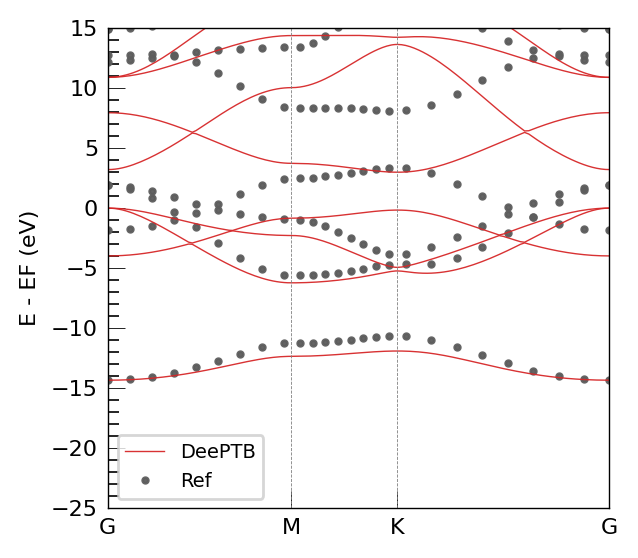

In [8]:
scc_HK = scc.cal_scc_hk(
    data=scc.data,
    per_atom_indices=scc.mulliken.per_atom_indices,
    scc_shift=scc.scc_shift,
)
H_converged = scc.data[AtomicDataDict.HAMILTONIAN_KEY].clone().to(dtype=scc.scc_cdtype) + scc_HK
S_band = scc.data[AtomicDataDict.OVERLAP_KEY].to(dtype=scc.scc_cdtype)

chklowt = torch.linalg.cholesky(S_band)
chklowtinv = torch.linalg.inv(chklowt)
H_eff = chklowtinv @ H_converged @ torch.transpose(chklowtinv, dim0=1, dim1=2).conj()
eigval, eigvec = torch.linalg.eigh(H_eff)
eigvec = torch.transpose(
    torch.transpose(chklowtinv, dim0=1, dim1=2).conj() @ eigvec,
    dim0=1,
    dim1=2,
)

scc.data[AtomicDataDict.ENERGY_EIGENVALUE_KEY] = torch.nested.as_nested_tensor([eigval])
scc.data[AtomicDataDict.EIGENVECTOR_KEY] = eigvec

eigenstatus_scc = {
    "klist": klist,
    "xlist": xlist,
    "high_sym_kpoints": high_sym_kpoints,
    "labels": labels,
    "eigenvalues": eigval.detach().cpu().numpy(),
    "E_fermi": E_fermi,
}

bcal_scc = Band(model=scc.model, results_path=None, device="cpu")
bcal_scc.eigenstatus = eigenstatus_scc
bcal_scc.band_plot(
    ref_band=str(ref_band),
    E_fermi=E_fermi,
    emin=kpath_kwargs.get("emin"),
    emax=kpath_kwargs.get("emax"),
)

For comparison, plot the same NNSK model without the SCC correction.

Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'B': 4.37, 'N': 4.18}
This is very dangerous, please make sure you know what you are doing.


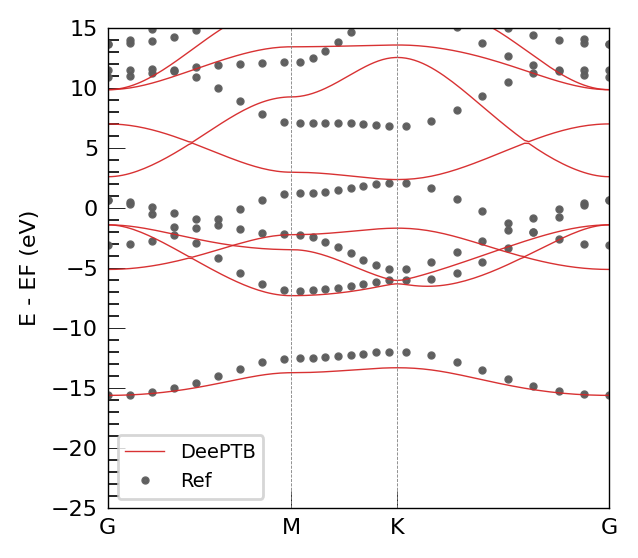

In [9]:
elec_noscc = ElecStruCal(model=model, device="cpu", eig_method="eigh")
data_noscc, eigs_noscc = elec_noscc.get_eigs(
    data=str(struct),
    klist=klist,
    AtomicData_options={"r_max": scc_params.r_max},
)

eigenstatus_noscc = {
    "klist": klist,
    "xlist": xlist,
    "high_sym_kpoints": high_sym_kpoints,
    "labels": labels,
    "eigenvalues": data_noscc[AtomicDataDict.ENERGY_EIGENVALUE_KEY][0].detach().cpu().numpy(),
    "E_fermi": E_fermi,
}

bcal_noscc = Band(model=model, results_path=None, device="cpu")
bcal_noscc.eigenstatus = eigenstatus_noscc
bcal_noscc.band_plot(
    ref_band=str(ref_band),
    E_fermi=E_fermi,
    emin=kpath_kwargs.get("emin"),
    emax=kpath_kwargs.get("emax"),
)

For a heavier comparison run, change `kmeshgrid` to `[20, 20, 1]` in the SCC cell above. The smaller mesh is the intended default for quick notebook verification.

In [12]:
import matplotlib.pyplot as plt

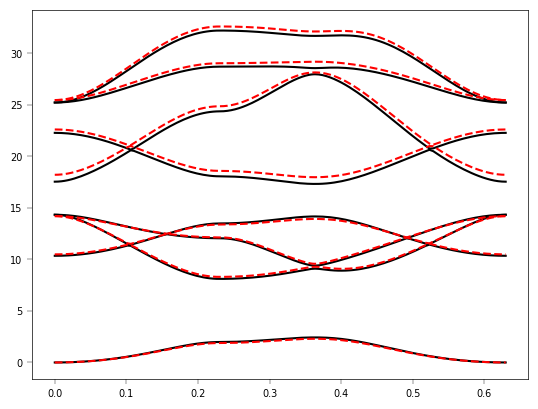

In [19]:

plt.plot(bcal_scc.eigenstatus['xlist'], 
         bcal_scc.eigenstatus["eigenvalues"]-bcal_scc.eigenstatus['eigenvalues'].min(),'k-')
plt.plot(bcal_noscc.eigenstatus['xlist'], 
         bcal_noscc.eigenstatus["eigenvalues"]-bcal_noscc.eigenstatus['eigenvalues'].min(),'r--')